# <u>Introduction</u>

<div style="border:2px solid black; padding:10px;">
Student performance prediction is an important application of machine learning in the field of education. By analyzing factors such as study habits, attendance, and previous academic results, it is possible to estimate how well a student may perform in an exam. In this project, machine learning techniques were used to predict student exam scores based on key behavioral and academic features. Exploratory Data Analysis (EDA) was first conducted to understand the dataset and identify important relationships between variables. After analyzing the data, a Linear Regression model from Scikit-learn was trained using selected features such as attendance, hours studied, and previous scores. The objective of this project is to develop a predictive model that can estimate student performance and help understand the factors that influence exam results.
</div>

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
import os
print(os.getcwd())

c:\Users\amrit\OneDrive\Documents\IBM PROJECT 2


In [10]:
df = pd.read_csv("2nd_data.csv")

In [11]:
import os

print(os.listdir())

['2nd_data.csv', 'app.py', 'IBM_INT2.ipynb', 'model.pkl', 'model.py', 'requirements.txt', 'templates', '__pycache__']


# 1) Exploratory Data Analysis (EDA)

### 1.1) Dataset Overview

In [12]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [13]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [14]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [15]:
data=df[['Hours_Studied',
         'Attendance',
         'Sleep_Hours',
         'Previous_Scores',
         'Tutoring_Sessions',
         'Exam_Score']]

In [16]:
data.head()
data.columns

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Exam_Score'],
      dtype='str')

In [17]:
data.dtypes

Hours_Studied        int64
Attendance           int64
Sleep_Hours          int64
Previous_Scores      int64
Tutoring_Sessions    int64
Exam_Score           int64
dtype: object

### 1.2) Descriptive Statistics

In [18]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,101.000000


### 1.3) Correlation Analysis

In [19]:
data.corr()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.156525
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,1.000000


### 1.4) Heatmap Visualization

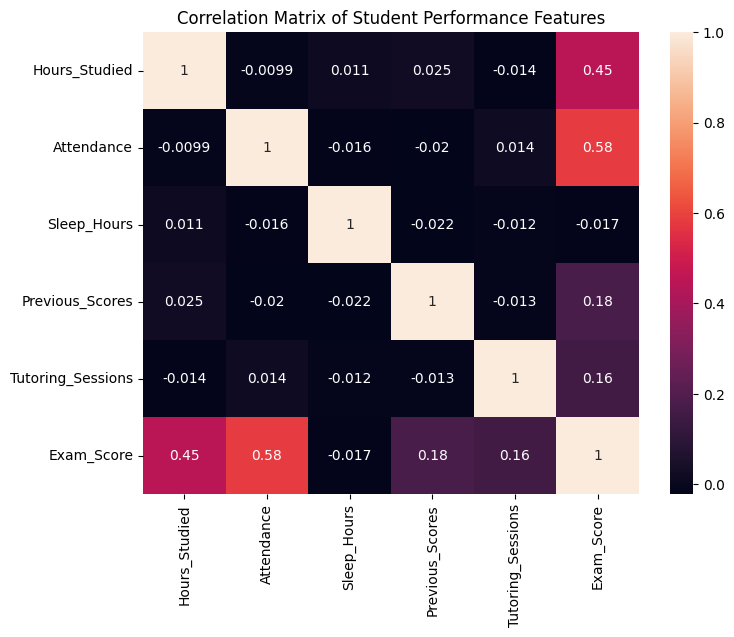

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix of Student Performance Features")
plt.show()

# 2)Machine Learning Model Development

### 2.1) Feature Selection

In [21]:
x=data[['Hours_Studied','Attendance','Previous_Scores']]
y=data['Exam_Score']
print(x.shape)
print(y.shape)

(6607, 3)
(6607,)


### 2.2) Train-Test Split

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5285, 3)
(1322, 3)
(5285,)
(1322,)


### 2.3) Linear Regression Model

In [23]:


model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pre=model.predict(x_test)
y_pre[:5]

array([66.02422558, 67.12132203, 68.68064739, 67.4221488 , 65.09835739])

In [25]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pre))

R2 Score: 0.6223383752199567


# 3) Model Evaluation

In [26]:
import joblib
joblib.dump(model, "model1.pkl")

['model1.pkl']